# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn

- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create

- Working classifiers and a simple comparison report


## Setup


In [1]:
import glob
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis


In [2]:
# extract the dataset zip to an output folder
ZIP_PATH = "Heart Disease Prediction Dataset.zip"  # or your path
EXTRACT_DIR = "heart_ds"
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(EXTRACT_DIR)

csv_files = glob.glob(os.path.join(EXTRACT_DIR, "**", "*.csv"), recursive=True)
csv_files


['heart_ds/dataset_heart.csv']

In [3]:
# list CSV files under EXTRACT_DIR
csv_path = csv_files[0]  # set to the CSV you choose

# load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# inspect df
print(df.shape)
display(df.head())

(270, 14)


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1


In [4]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting blood pressure,0
serum cholestoral,0
fasting blood sugar,0
resting electrocardiographic results,0
max heart rate,0
exercise induced angina,0
oldpeak,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print(df["heart disease"].dtype)
df["heart disease"].value_counts()

int64


,count
heart disease,
1,150
2,120


In [7]:
df["heart disease"] = df["heart disease"].map({1: 0, 2: 1})
df["heart disease"].value_counts()

,count
heart disease,
0,150
1,120


In [8]:
df.columns = df.columns.str.strip()  # Identified columns with trailing whitespaces

In [9]:
# identify target column
target = "heart disease"  # 'target'

# split features and target
X = df.drop(columns=[target])  # df.drop(columns=[...])
y = df[target]  # df[...]

In [10]:
# train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(216, 13)
(54, 13)
heart disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64
heart disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64


### Basic visual checks


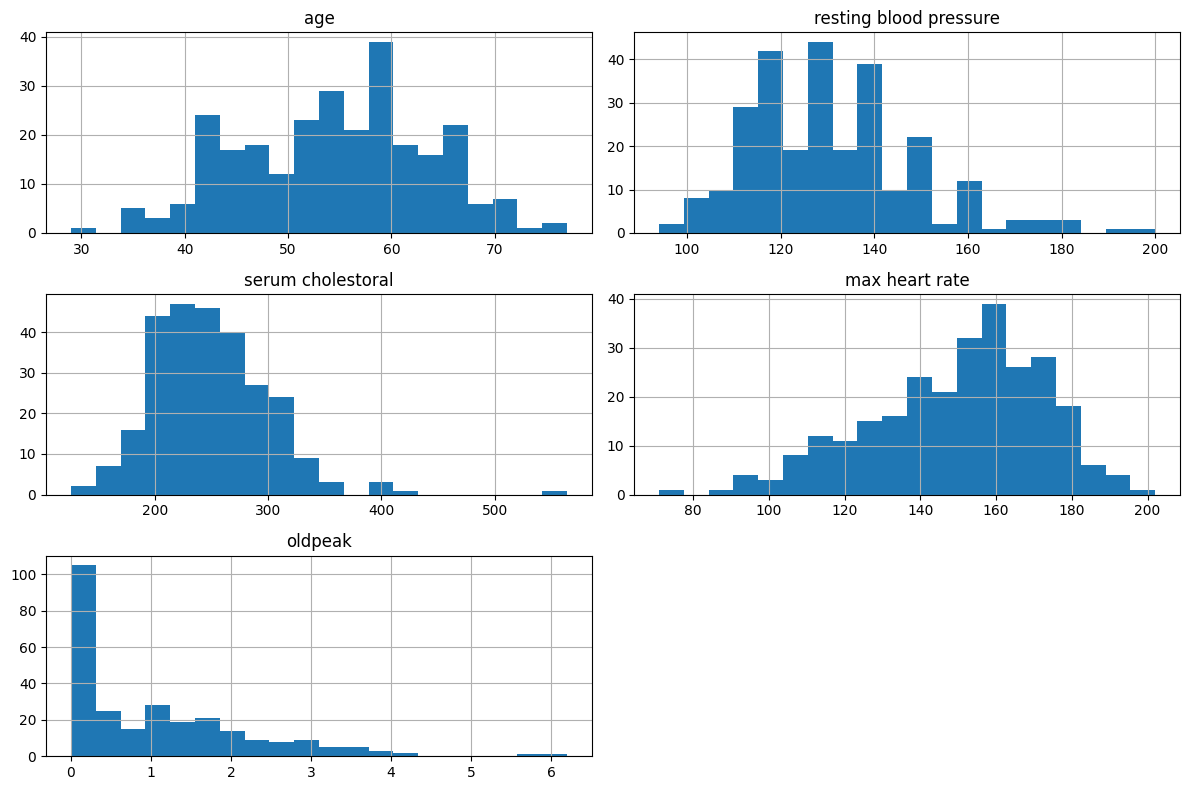

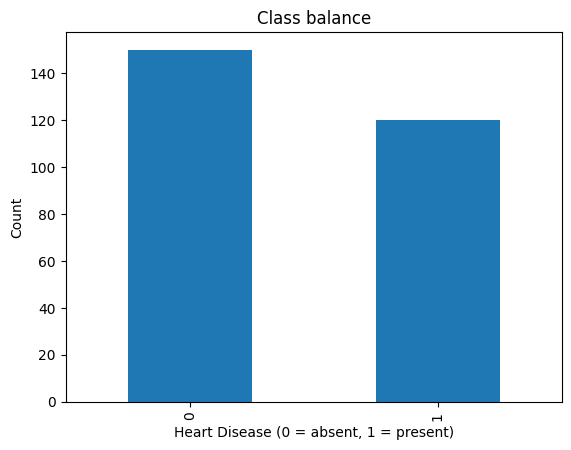

In [11]:
# pick a few numeric columns and plot histograms
continuous_cols = [
    "age",
    "resting blood pressure",
    "serum cholestoral",
    "max heart rate",
    "oldpeak",
]
df[continuous_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# plot class balance as a bar chart
df["heart disease"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Heart Disease (0 = absent, 1 = present)")
plt.ylabel("Count")
plt.title("Class balance")
plt.show()

## Preprocessing pipeline


In [12]:
X.nunique().sort_values()

,0
sex,2
fasting blood sugar,2
exercise induced angina,2
resting electrocardiographic results,3
ST segment,3
thal,3
major vessels,4
chest pain type,4
oldpeak,39
age,41


In [13]:
cat_cols = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting electrocardiographic results",
    "exercise induced angina",
    "ST segment",
    "major vessels",
    "thal",
]  # list of object, category, or bool columns
num_cols = [
    "age",
    "resting blood pressure",
    "serum cholestoral",
    "max heart rate",
    "oldpeak",
]  # list of numeric columns

# build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ]
)


## Helper - evaluation function


In [14]:
def eval_and_report(name: str, model, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    """
    Score a filtered classifier on the test set and plot its confusion matrix and ROC curve.

    Args:
        name (str): Label used in printed output and plot titles.
        model: A fitted classifier or Pipeline exposing predict() (and predict_proba() for ROC).
        X_test (pd.DataFrame): Held-out feature rows to score against.
        y_test (pd.Series): True labels for X_test.

    Returns:
        dict: accuracy, precision, recall, and f1 for this model on the test set.
    """
    # predictions
    y_pred = model.predict(X_test)

    # compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }
    print(name, metrics)

    # confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} - confusion matrix")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{name} - ROC curve")
        plt.legend()
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search


LR no grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


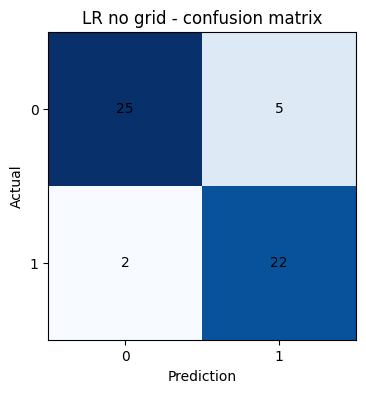

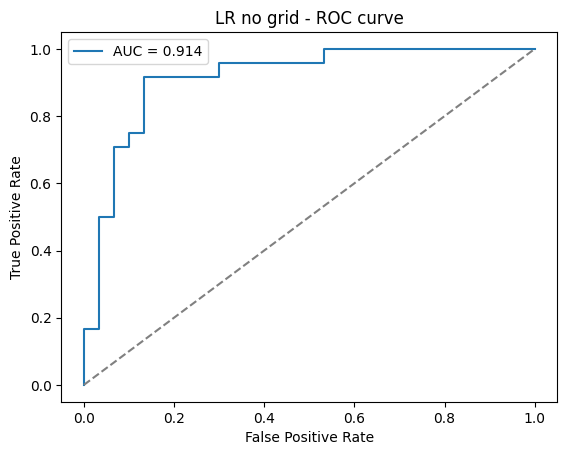

In [15]:
# create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline(
    [
        ("pre", pre),
        (
            "lr",
            LogisticRegression(
                solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
            ),
        ),
    ]
)

# fit on training data
# pipe_lr.fit(...)
pipe_lr.fit(X_train, y_train)

# evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report("LR no grid", pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search


Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}
LR grid {'accuracy': 0.8703703703703703, 'precision': 0.8148148148148148, 'recall': 0.9166666666666666, 'f1': 0.8627450980392157}


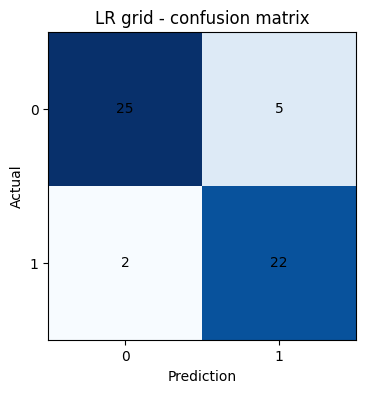

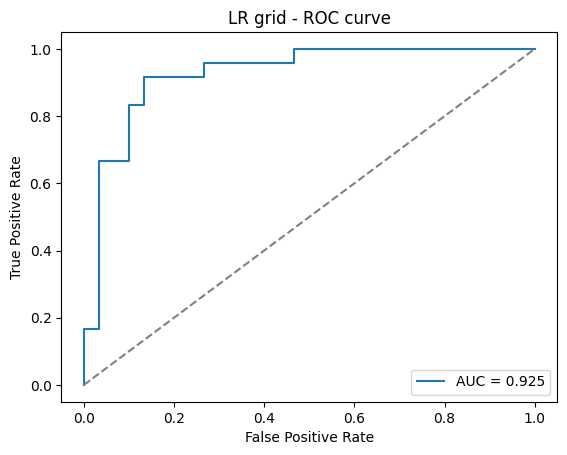

In [16]:
# build a Pipeline same as above
pipe_lr_cv = Pipeline(
    [
        ("pre", pre),
        (
            "lr",
            LogisticRegression(
                solver="liblinear", max_iter=1000, random_state=RANDOM_STATE
            ),
        ),
    ]
)

# define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {"lr__C": [0.01, 0.1, 1, 10, 100], "lr__penalty": ["l1", "l2"]}

# GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring="f1")
grid_lr.fit(X_train, y_train)
print("Best params:", grid_lr.best_params_)

best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report("LR grid", best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search


SVM no grid {'accuracy': 0.8518518518518519, 'precision': 0.7857142857142857, 'recall': 0.9166666666666666, 'f1': 0.8461538461538461}


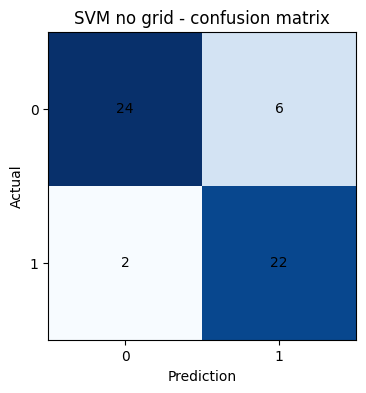

In [17]:
# choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(
    [
        ("pre", pre),
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
    ]
)

pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report("SVM no grid", pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search


Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8076923076923077, 'recall': 0.875, 'f1': 0.84}


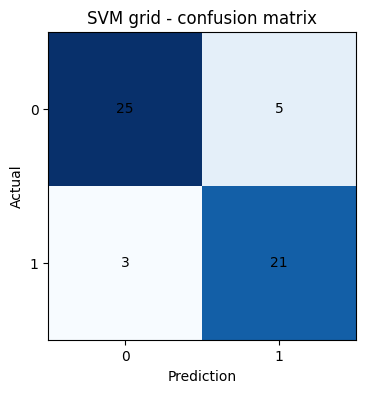

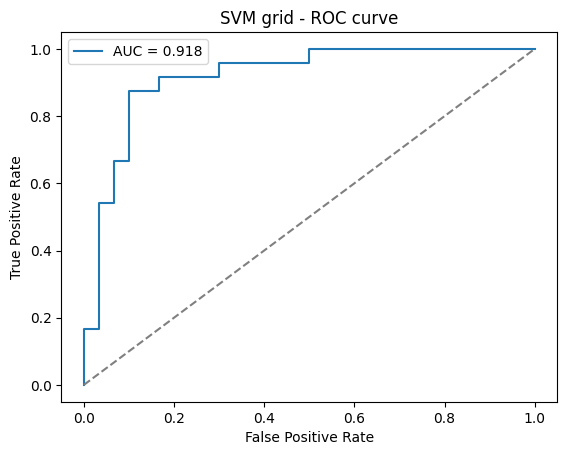

In [18]:
# Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(
    [("pre", pre), ("svm", SVC(probability=True, random_state=RANDOM_STATE))]
)

# param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    "svm__kernel": ["rbf", "linear"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
}

# GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring="f1")
grid_svm.fit(X_train, y_train)

print(f"Best params: {grid_svm.best_params_}")

best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report("SVM grid", best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search


XGB no grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


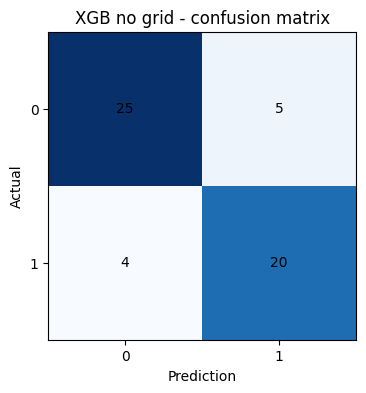

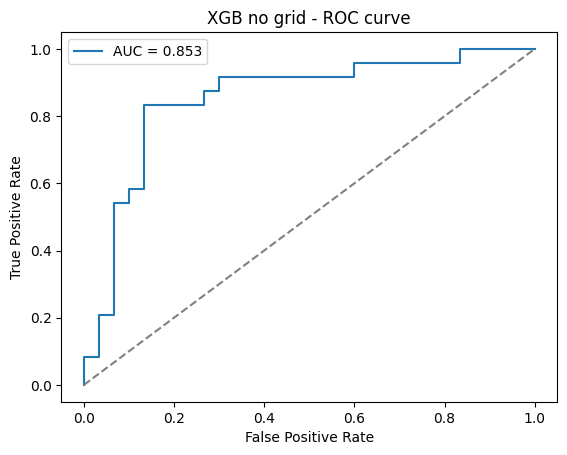

In [19]:
# build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline(
    [
        ("pre", pre),
        (
            "xgb",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.1,
                max_depth=4,
                random_state=RANDOM_STATE,
                eval_metric="logloss",
            ),
        ),
    ]
)
pipe_xgb.fit(X_train, y_train)

xgb_no_metrics = eval_and_report("XGB no grid", pipe_xgb, X_test, y_test)

## Exercise 7 - XGBoost with Grid Search


Best params: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200, 'xgb__subsample': 0.8}
XGB grid {'accuracy': 0.7962962962962963, 'precision': 0.7407407407407407, 'recall': 0.8333333333333334, 'f1': 0.7843137254901961}


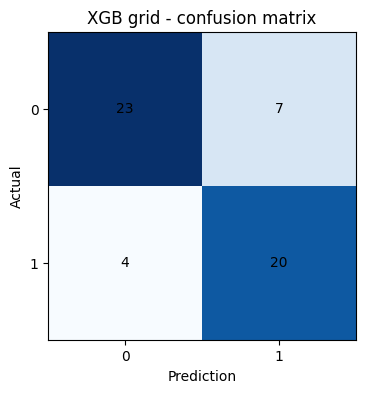

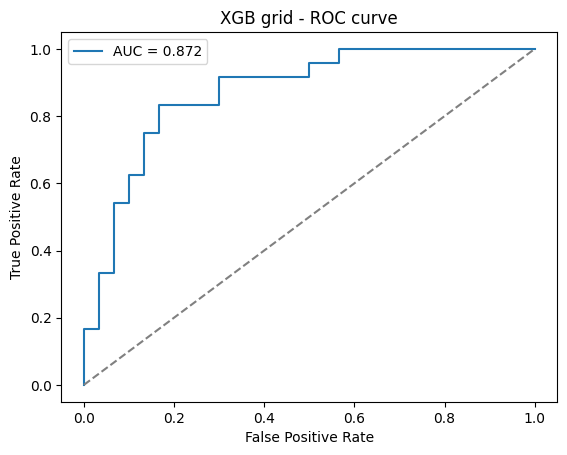

In [20]:
# Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(
    [
        ("pre", pre),
        ("xgb", XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss")),
    ]
)

# define a reasonable param_grid
xgb_param_grid = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__learning_rate": [0.01, 0.1, 0.2],
    "xgb__max_depth": [2, 3, 4],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}

# GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring="f1")
grid_xgb.fit(X_train, y_train)

print(f"Best params: {grid_xgb.best_params_}")

best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report("XGB grid", best_xgb, X_test, y_test)

## Compare models


In [21]:
# build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary = {}
summary["LR no grid"] = lr_no_gs_metrics
# ... add others you computed ...
summary["LR grid"] = lr_gs_metrics
summary["SVM no grid"] = svm_no_metrics
summary["SVM grid"] = svm_gs_metrics
summary["XGB no grid"] = xgb_no_metrics
summary["XGB grid"] = xgb_gs_metrics

comparison = pd.DataFrame.from_dict(summary, orient="index")
comparison

,accuracy,precision,recall,f1
LR no grid,0.870370,0.814815,0.916667,0.862745
LR grid,0.870370,0.814815,0.916667,0.862745
SVM no grid,0.851852,0.785714,0.916667,0.846154
SVM grid,0.851852,0.807692,0.875000,0.840000
XGB no grid,0.833333,0.800000,0.833333,0.816327
XGB grid,0.796296,0.740741,0.833333,0.784314
